# Proyecto ML2 — Clasificación del riesgo crediticio

##Nicolás Barrera - Angie Loango

## Segunda entrega: datos, modelamiento y validación


In [1]:
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

SEED = 42
np.random.seed(SEED)

N = 5000


## Entorno reproducible

La ejecución final se realizó con Python 3.13.5, numpy 2.3.5, pandas 2.2.3, scipy 1.17.0, scikit-learn 1.8.0, xgboost 3.1.3, lightgbm 4.6.0, matplotlib 3.10.8 y openpyxl 3.1.5. Las mismas versiones se fijan en requirements.txt.


# Bloque 1 — Perfil socioeconómico

Se simulan edad, ocupación, formalidad, antigüedad laboral, ingreso y variabilidad del ingreso.
La edad se genera con una normal truncada entre 18 y 75 años para evitar acumulaciones artificiales en los extremos.


In [2]:
media_edad = 38
desviacion_edad = 12
edad_min = 18
edad_max = 75

a = (edad_min - media_edad) / desviacion_edad
b = (edad_max - media_edad) / desviacion_edad

edad = truncnorm.rvs(
    a,
    b,
    loc=media_edad,
    scale=desviacion_edad,
    size=N,
    random_state=SEED + 1
)

edad = np.round(edad).astype(int)


In [3]:
tipo_ocupacion = []

for e in edad:

    if e < 23:
        ocupacion = np.random.choice(
            ["Dependiente", "Independiente", "Cuenta propia", "Desempleado"],
            p=[0.40, 0.10, 0.20, 0.30]
        )

    elif e < 55:
        ocupacion = np.random.choice(
            ["Dependiente", "Independiente", "Cuenta propia", "Desempleado"],
            p=[0.55, 0.22, 0.18, 0.05]
        )

    elif e < 62:
        ocupacion = np.random.choice(
            ["Dependiente", "Independiente", "Cuenta propia", "Desempleado", "Pensionado"],
            p=[0.40, 0.22, 0.18, 0.08, 0.12]
        )

    else:
        ocupacion = np.random.choice(
            ["Dependiente", "Independiente", "Cuenta propia", "Desempleado", "Pensionado"],
            p=[0.20, 0.15, 0.15, 0.05, 0.45]
        )

    tipo_ocupacion.append(ocupacion)

tipo_ocupacion = np.array(tipo_ocupacion)


In [4]:
formalidad_laboral = []

for ocupacion in tipo_ocupacion:

    if ocupacion == "Dependiente":
        formalidad = np.random.choice(
            ["Formal", "Informal"],
            p=[0.90, 0.10]
        )

    elif ocupacion == "Independiente":
        formalidad = np.random.choice(
            ["Formal", "Informal"],
            p=[0.55, 0.45]
        )

    elif ocupacion == "Cuenta propia":
        formalidad = np.random.choice(
            ["Formal", "Informal"],
            p=[0.20, 0.80]
        )

    else:
        formalidad = "No aplica"

    formalidad_laboral.append(formalidad)

formalidad_laboral = np.array(formalidad_laboral)


In [5]:
antiguedad_laboral = []

for e, ocupacion, formalidad in zip(
    edad,
    tipo_ocupacion,
    formalidad_laboral
):

    # Máximo de meses que una persona podría haber trabajado
    # suponiendo que comenzó a trabajar a los 18 años
    max_meses = max((e - 18) * 12, 0)

    if ocupacion == "Desempleado":
        meses = 0

    elif ocupacion == "Pensionado":
        # Para pensionados, simulamos una trayectoria laboral más larga
        meses = int(np.random.gamma(shape=8, scale=24))
        meses = min(meses, max_meses)

    elif formalidad == "Formal":
        # Mayor estabilidad laboral promedio
        meses = int(np.random.gamma(shape=4, scale=18))
        meses = min(meses, max_meses)

    else:
        # Mayor rotación laboral para empleo informal
        meses = int(np.random.gamma(shape=2.5, scale=14))
        meses = min(meses, max_meses)

    antiguedad_laboral.append(meses)

antiguedad_laboral = np.array(antiguedad_laboral)


In [6]:
# INGRESO MENSUAL
# El ingreso depende de edad, ocupación y formalidad.
# Para desempleados se permite ingreso cero o ingreso no laboral.

ingreso_mensual = []

for e, ocupacion, formalidad in zip(
    edad,
    tipo_ocupacion,
    formalidad_laboral
):

    # Factor suave de experiencia: no determina el ingreso,
    # solo modifica ligeramente su distribución.
    factor_edad = 0.75 + min(max(e - 18, 0), 30) / 100

    if ocupacion == "Dependiente" and formalidad == "Formal":
        ingreso = np.random.lognormal(
            mean=np.log(3_800_000),
            sigma=0.45
        ) * factor_edad

    elif ocupacion == "Dependiente":
        ingreso = np.random.lognormal(
            mean=np.log(2_600_000),
            sigma=0.55
        ) * factor_edad

    elif ocupacion == "Independiente" and formalidad == "Formal":
        ingreso = np.random.lognormal(
            mean=np.log(4_200_000),
            sigma=0.65
        ) * factor_edad

    elif ocupacion == "Independiente":
        ingreso = np.random.lognormal(
            mean=np.log(2_800_000),
            sigma=0.75
        ) * factor_edad

    elif ocupacion == "Cuenta propia":
        ingreso = np.random.lognormal(
            mean=np.log(2_200_000),
            sigma=0.70
        ) * factor_edad

    elif ocupacion == "Pensionado":
        ingreso = np.random.lognormal(
            mean=np.log(2_500_000),
            sigma=0.45
        )

    elif ocupacion == "Desempleado":
        # 40 % sin ingreso mensual y 60 % con ingresos no laborales/ocasionales.
        if np.random.random() < 0.40:
            ingreso = 0
        else:
            ingreso = np.random.lognormal(
                mean=np.log(900_000),
                sigma=0.55
            )

    else:
        ingreso = 0

    if ingreso > 0:
        ingreso = np.clip(
            ingreso,
            300_000,
            30_000_000
        )

    ingreso_mensual.append(round(ingreso, -3))

ingreso_mensual = np.array(ingreso_mensual)


In [7]:
variabilidad_ingreso = []

for ocupacion, formalidad in zip(
    tipo_ocupacion,
    formalidad_laboral
):

    if ocupacion == "Dependiente" and formalidad == "Formal":
        valor = np.random.beta(2, 12)

    elif ocupacion == "Dependiente":
        valor = np.random.beta(2, 7)

    elif ocupacion == "Independiente":
        valor = np.random.beta(3, 5)

    elif ocupacion == "Cuenta propia":
        valor = np.random.beta(3.5, 4)

    elif ocupacion == "Desempleado":
        valor = np.random.beta(5, 2)

    else:
        valor = np.random.beta(2, 9)

    variabilidad_ingreso.append(valor)

variabilidad_ingreso = np.round(
    np.array(variabilidad_ingreso),
    3
)


In [8]:
df = pd.DataFrame({
    "Edad": edad,
    "Tipo_Ocupacion": tipo_ocupacion,
    "Formalidad_Laboral": formalidad_laboral,
    "Antiguedad_Laboral_Meses": antiguedad_laboral,
    "Ingreso_Mensual": ingreso_mensual,
    "Variabilidad_Ingreso": variabilidad_ingreso
})


In [9]:
# ANTIGÜEDAD LABORAL EN AÑOS
# La variable original se conserva en meses.
# Esta columna adicional facilita la revisión visual.

df["Antiguedad_Laboral_Años"] = (
    df["Antiguedad_Laboral_Meses"] / 12
).round(1)

df[
    [
        "Edad",
        "Tipo_Ocupacion",
        "Formalidad_Laboral",
        "Antiguedad_Laboral_Meses",
        "Antiguedad_Laboral_Años"
    ]
].head(20)


,Edad,Tipo_Ocupacion,Formalidad_Laboral,Antiguedad_Laboral_Meses,Antiguedad_Laboral_Años
0,26,Dependiente,Formal,65,5.4
1,42,Desempleado,No aplica,0,0.0
2,27,Independiente,Formal,106,8.8
3,31,Independiente,Informal,27,2.2
4,34,Dependiente,Formal,49,4.1
5,51,Dependiente,Formal,44,3.7
6,44,Dependiente,Formal,39,3.2
7,40,Cuenta propia,Informal,20,1.7
8,21,Cuenta propia,Informal,36,3.0
9,46,Independiente,Formal,67,5.6


In [10]:
resumen_ocupacion_edad = pd.crosstab(
    pd.cut(
        df["Edad"],
        bins=[17, 22, 54, 61, 75],
        labels=["18-22", "23-54", "55-61", "62-75"]
    ),
    df["Tipo_Ocupacion"],
    normalize="index"
).round(3)

print("Conteo por ocupación:")
print(df["Tipo_Ocupacion"].value_counts())
print()
print("Proporción por grupo de edad:")
resumen_ocupacion_edad


Conteo por ocupación:
Tipo_Ocupacion
Dependiente      2625
Independiente    1066
Cuenta propia     876
Desempleado       331
Pensionado        102
Name: count, dtype: int64

Proporción por grupo de edad:


Tipo_Ocupacion,Cuenta propia,Dependiente,Desempleado,Independiente,Pensionado
Edad,,,,,
18-22,0.174,0.411,0.320,0.095,0.000
23-54,0.175,0.555,0.049,0.221,0.000
55-61,0.187,0.335,0.109,0.233,0.136
62-75,0.140,0.215,0.041,0.132,0.471


## Fundamentación del contexto colombiano
La simulación toma fuentes oficiales como referencia para que los datos tengan sentido dentro del contexto colombiano, pero no busca copiar exactamente la realidad. La GEIH del DANE se utilizó para orientar las diferencias en ingresos y condiciones laborales; la UGPP sirvió como referencia para la base de cotización de los trabajadores independientes; y la Superintendencia Financiera, junto con Banca de las Oportunidades, aportó contexto sobre acceso al crédito, productos financieros, cartera y mora.
Sin embargo, los valores específicos usados para generar los datos, como medias, desviaciones, probabilidades y límites, fueron definidos por el equipo como supuestos de simulación. Por esta razón, el dataset debe entenderse como un escenario sintético y razonable, no como una representación exacta de la población colombiana.

# Bloque 2 — Cotización y contexto colombiano

Se incorporan Tipo_Cotizante, Meses_Cotizados_12M e IBC_Aproximado, condicionados por ocupación, formalidad, edad, antigüedad e ingreso.


In [11]:
# BLOQUE 2 — TIPO DE COTIZANTE

tipo_cotizante = []

for ocupacion, formalidad in zip(
    df["Tipo_Ocupacion"],
    df["Formalidad_Laboral"]
):

    if ocupacion == "Dependiente" and formalidad == "Formal":
        cotizante = "Dependiente"

    elif ocupacion in ["Independiente", "Cuenta propia"] and formalidad == "Formal":
        cotizante = "Independiente"

    elif ocupacion == "Pensionado":
        cotizante = "Pensionado"

    else:
        cotizante = "Sin cotizacion"

    tipo_cotizante.append(cotizante)

df["Tipo_Cotizante"] = tipo_cotizante


In [12]:
# MESES COTIZADOS EN LOS ÚLTIMOS 12 MESES
# S POR EDAD Y ANTIGÜEDAD

meses_cotizados = []

for edad_i, antiguedad_meses, cotizante in zip(
    df["Edad"],
    df["Antiguedad_Laboral_Meses"],
    df["Tipo_Cotizante"]
):

    # Máximo de meses que podría haber cotizado
    # dentro de nuestro supuesto de inicio laboral a los 18 años.
    max_meses_posibles = min(
        12,
        max((edad_i - 18) * 12, 0),
        antiguedad_meses if antiguedad_meses > 0 else 0
    )

    if cotizante == "Dependiente":

        if max_meses_posibles == 0:
            meses = 0
        else:
            posibles = np.arange(1, max_meses_posibles + 1)

            # Favorecemos valores altos para dependientes formales
            pesos = posibles ** 3
            pesos = pesos / pesos.sum()

            meses = np.random.choice(
                posibles,
                p=pesos
            )

    elif cotizante == "Independiente":

        if max_meses_posibles == 0:
            meses = 0
        else:
            posibles = np.arange(1, max_meses_posibles + 1)

            # Distribución más flexible que la de dependientes
            pesos = posibles ** 1.2
            pesos = pesos / pesos.sum()

            meses = np.random.choice(
                posibles,
                p=pesos
            )

    elif cotizante == "Pensionado":

        # No lo interpretamos como meses trabajados,
        # sino como permanencia en el sistema durante el año.
        meses = 12

    else:

        meses = 0

    meses_cotizados.append(meses)

df["Meses_Cotizados_12M"] = meses_cotizados


In [13]:
# IBC APROXIMADO

ibc_aproximado = []

for ingreso, cotizante, meses in zip(
    df["Ingreso_Mensual"],
    df["Tipo_Cotizante"],
    df["Meses_Cotizados_12M"]
):

    # Si no cotizó durante el año, el IBC sintético es 0
    if meses == 0 or ingreso <= 0:
        ibc = 0

    elif cotizante == "Dependiente":

        # Aproximamos el IBC al ingreso laboral,
        # introduciendo una pequeña variación.
        factor = np.random.normal(
            loc=1.00,
            scale=0.04
        )

        factor = np.clip(
            factor,
            0.90,
            1.10
        )

        ibc = ingreso * factor

    elif cotizante == "Independiente":

        # Simplificación sintética inspirada en la regla
        # del 40 % sobre ingresos netos.
        factor = np.random.normal(
            loc=0.40,
            scale=0.04
        )

        factor = np.clip(
            factor,
            0.32,
            0.48
        )

        ibc = ingreso * factor

    elif cotizante == "Pensionado":

        # Proxy del valor base asociado a la mesada
        factor = np.random.normal(
            loc=1.00,
            scale=0.03
        )

        factor = np.clip(
            factor,
            0.92,
            1.08
        )

        ibc = ingreso * factor

    else:
        ibc = 0

    if ibc > 0:
        ibc = np.clip(
            ibc,
            300_000,
            30_000_000
        )

    ibc_aproximado.append(
        round(ibc, -3)
    )

df["IBC_Aproximado"] = ibc_aproximado


# Bloque 3 — Perfil e historial crediticio

Se simulan antigüedad crediticia, productos financieros, préstamos, tenencia de tarjeta, límite, saldo y utilización del crédito.


In [14]:
# BLOQUE 3 — ANTIGÜEDAD CREDITICIA

antiguedad_crediticia = []

for edad_i, ingreso_i in zip(
    df["Edad"],
    df["Ingreso_Mensual"]
):

    max_meses_posibles = max((edad_i - 18) * 12, 0)

    if max_meses_posibles == 0:
        meses_credito = 0

    else:
        # Personas con mayor edad tienden a tener más historial,
        # pero con variabilidad.
        meses_credito = int(
            np.random.beta(2.5, 2.0) * max_meses_posibles
        )

        # Si no hay ingreso, reducimos la antigüedad esperada
        if ingreso_i == 0:
            meses_credito = int(meses_credito * 0.5)

        meses_credito = min(
            meses_credito,
            max_meses_posibles
        )

    antiguedad_crediticia.append(meses_credito)

df["Antiguedad_Crediticia_Meses"] = antiguedad_crediticia


In [15]:
# NÚMERO DE PRODUCTOS FINANCIEROS

numero_productos = []

for ingreso, antig_credito in zip(
    df["Ingreso_Mensual"],
    df["Antiguedad_Crediticia_Meses"]
):

    if antig_credito == 0:
        productos = np.random.choice(
            [0, 1],
            p=[0.75, 0.25]
        )

    elif ingreso < 1_500_000:
        productos = np.random.choice(
            [1, 2, 3],
            p=[0.55, 0.35, 0.10]
        )

    elif ingreso < 4_000_000:
        productos = np.random.choice(
            [1, 2, 3, 4],
            p=[0.20, 0.40, 0.30, 0.10]
        )

    elif ingreso < 8_000_000:
        productos = np.random.choice(
            [2, 3, 4, 5],
            p=[0.20, 0.35, 0.30, 0.15]
        )

    else:
        productos = np.random.choice(
            [2, 3, 4, 5, 6],
            p=[0.10, 0.20, 0.30, 0.25, 0.15]
        )

    numero_productos.append(productos)

df["Numero_Productos_Financieros"] = numero_productos


In [16]:
# NÚMERO DE PRÉSTAMOS

numero_prestamos = []

for productos, antig_credito in zip(
    df["Numero_Productos_Financieros"],
    df["Antiguedad_Crediticia_Meses"]
):

    if antig_credito == 0 or productos == 0:
        prestamos = 0

    elif productos == 1:
        prestamos = np.random.choice(
            [0, 1],
            p=[0.70, 0.30]
        )

    elif productos <= 3:
        prestamos = np.random.choice(
            [0, 1, 2],
            p=[0.35, 0.50, 0.15]
        )

    else:
        prestamos = np.random.choice(
            [0, 1, 2, 3],
            p=[0.20, 0.45, 0.25, 0.10]
        )

    numero_prestamos.append(prestamos)

df["Numero_Prestamos"] = numero_prestamos


In [17]:
# TENENCIA DE TARJETA DE CRÉDITO

tiene_tarjeta = []

for ingreso, productos, antig_credito in zip(
    df["Ingreso_Mensual"],
    df["Numero_Productos_Financieros"],
    df["Antiguedad_Crediticia_Meses"]
):

    if productos == 0 or antig_credito == 0:
        tiene = 0

    elif ingreso == 0:
        # Puede conservar una tarjeta previa,
        # pero con menor probabilidad.
        tiene = np.random.choice(
            [0, 1],
            p=[0.80, 0.20]
        )

    elif ingreso < 1_500_000:
        tiene = np.random.choice(
            [0, 1],
            p=[0.65, 0.35]
        )

    elif ingreso < 4_000_000:
        tiene = np.random.choice(
            [0, 1],
            p=[0.35, 0.65]
        )

    elif ingreso < 8_000_000:
        tiene = np.random.choice(
            [0, 1],
            p=[0.20, 0.80]
        )

    else:
        tiene = np.random.choice(
            [0, 1],
            p=[0.10, 0.90]
        )

    tiene_tarjeta.append(tiene)

df["Tiene_Tarjeta_Credito"] = tiene_tarjeta


In [18]:
# LÍMITE DE TARJETA

limite_tarjeta = []

for ingreso, tiene_tarjeta, antig_credito in zip(
    df["Ingreso_Mensual"],
    df["Tiene_Tarjeta_Credito"],
    df["Antiguedad_Crediticia_Meses"]
):

    if tiene_tarjeta == 0:
        limite = 0

    else:

        # Si actualmente no tiene ingreso,
        # puede conservar una tarjeta previa con límite bajo/moderado.
        if ingreso == 0:

            limite = np.random.lognormal(
                mean=np.log(1_500_000),
                sigma=0.40
            )

        else:

            factor = np.random.lognormal(
                mean=np.log(1.3),
                sigma=0.45
            )

            limite = ingreso * factor

        limite = np.clip(
            limite,
            500_000,
            40_000_000
        )

    limite_tarjeta.append(
        round(limite, -3)
    )

df["Limite_Tarjeta"] = limite_tarjeta


In [19]:
# SALDO DE TARJETA

saldo_tarjeta = []

for limite, ingreso in zip(
    df["Limite_Tarjeta"],
    df["Ingreso_Mensual"]
):

    if limite == 0:
        saldo = 0

    else:
        # Distribución con mayor concentración
        # en utilizaciones bajas y medias.
        utilizacion_base = np.random.beta(
            2.2,
            3.0
        )

        saldo = limite * utilizacion_base

        saldo = min(
            saldo,
            limite
        )

    saldo_tarjeta.append(
        round(saldo, -3)
    )

df["Saldo_Tarjeta"] = saldo_tarjeta


In [20]:
# UTILIZACIÓN DEL CRÉDITO

df["Utilizacion_Credito"] = np.where(
    df["Limite_Tarjeta"] > 0,
    df["Saldo_Tarjeta"] / df["Limite_Tarjeta"],
    0
)

df["Utilizacion_Credito"] = (
    df["Utilizacion_Credito"]
    .clip(0, 1)
    .round(3)
)


# Bloque 4 — Comportamiento financiero y señales de riesgo

Se generan deuda pendiente, ratio deuda/ingreso, comportamiento de pago, monto pagado de tarjeta, retrasos, mora y consultas de crédito.


In [21]:
# BLOQUE 4 — DEUDA PENDIENTE

deuda_pendiente = []

for ingreso, prestamos, saldo_tarjeta in zip(
    df["Ingreso_Mensual"],
    df["Numero_Prestamos"],
    df["Saldo_Tarjeta"]
):

    deuda_base = saldo_tarjeta

    if prestamos == 0:
        deuda_extra = 0

    else:
        # Deuda adicional asociada a préstamos
        factor = np.random.lognormal(
            mean=np.log(2.0),
            sigma=0.65
        )

        deuda_extra = ingreso * prestamos * factor

    deuda_total = deuda_base + deuda_extra

    deuda_total = np.clip(
        deuda_total,
        0,
        150_000_000
    )

    deuda_pendiente.append(
        round(deuda_total, -3)
    )

df["Deuda_Pendiente"] = deuda_pendiente


In [22]:
# RATIO DEUDA / INGRESO ANUAL

ingreso_anual = df["Ingreso_Mensual"] * 12

df["Ratio_Deuda_Ingreso"] = np.where(
    ingreso_anual > 0,
    df["Deuda_Pendiente"] / ingreso_anual,
    np.where(
        df["Deuda_Pendiente"] > 0,
        2.0,
        0.0
    )
)

df["Ratio_Deuda_Ingreso"] = (
    df["Ratio_Deuda_Ingreso"]
    .clip(0, 3)
    .round(3)
)


In [23]:
# COMPORTAMIENTO DE PAGO DE TARJETA

comportamiento_pago = []

for tiene_tarjeta, utilizacion, ratio_deuda, variabilidad in zip(
    df["Tiene_Tarjeta_Credito"],
    df["Utilizacion_Credito"],
    df["Ratio_Deuda_Ingreso"],
    df["Variabilidad_Ingreso"]
):

    if tiene_tarjeta == 0:
        comportamiento = "No aplica"

    else:

        # Riesgo financiero sintético
        riesgo = (
            0.50 * utilizacion +
            0.30 * min(ratio_deuda / 1.5, 1) +
            0.20 * variabilidad
        )

        # Ruido para evitar una relación determinista
        riesgo += np.random.normal(
            loc=0,
            scale=0.12
        )

        riesgo = np.clip(
            riesgo,
            0,
            1
        )

        if riesgo < 0.25:
            comportamiento = "Pago total"

        elif riesgo < 0.50:
            comportamiento = "Pago superior al mínimo"

        elif riesgo < 0.70:
            comportamiento = "Pago mínimo"

        else:
            comportamiento = "Pago irregular"

    comportamiento_pago.append(comportamiento)

df["Comportamiento_Pago_Tarjeta"] = comportamiento_pago


In [24]:
# MONTO PAGADO DE TARJETA

monto_pagado_tarjeta = []

for saldo, comportamiento in zip(
    df["Saldo_Tarjeta"],
    df["Comportamiento_Pago_Tarjeta"]
):

    if saldo == 0 or comportamiento == "No aplica":
        pago = 0

    else:

        if comportamiento == "Pago total":
            proporcion = np.random.uniform(0.80, 1.00)

        elif comportamiento == "Pago superior al mínimo":
            proporcion = np.random.uniform(0.20, 0.50)

        elif comportamiento == "Pago mínimo":
            proporcion = np.random.uniform(0.05, 0.15)

        else:
            proporcion = np.random.uniform(0.00, 0.08)

        pago = saldo * proporcion

    monto_pagado_tarjeta.append(
        round(pago, -3)
    )

df["Monto_Pagado_Tarjeta"] = monto_pagado_tarjeta


In [25]:
# NÚMERO DE RETRASOS EN LOS ÚLTIMOS 12 MESES

numero_retrasos = []

for comportamiento, ratio_deuda, variabilidad, prestamos, saldo in zip(
    df["Comportamiento_Pago_Tarjeta"],
    df["Ratio_Deuda_Ingreso"],
    df["Variabilidad_Ingreso"],
    df["Numero_Prestamos"],
    df["Saldo_Tarjeta"]
):

    # Primero comprobamos si existe alguna obligación crediticia
    tiene_obligacion = (
        prestamos > 0 or
        saldo > 0
    )

    if not tiene_obligacion:

        retrasos = 0

    else:

        # Riesgo base según comportamiento de pago
        if comportamiento == "Pago total":

            riesgo_retraso = (
                0.05 +
                0.15 * min(ratio_deuda / 1.5, 1) +
                0.15 * variabilidad
            )

        elif comportamiento == "Pago superior al mínimo":

            riesgo_retraso = (
                0.15 +
                0.20 * min(ratio_deuda / 1.5, 1) +
                0.20 * variabilidad
            )

        elif comportamiento == "Pago mínimo":

            riesgo_retraso = (
                0.30 +
                0.25 * min(ratio_deuda / 1.5, 1) +
                0.20 * variabilidad
            )

        elif comportamiento == "Pago irregular":

            riesgo_retraso = (
                0.50 +
                0.25 * min(ratio_deuda / 1.5, 1) +
                0.20 * variabilidad
            )

        else:
            # No tiene tarjeta, pero sí puede tener préstamos
            riesgo_retraso = (
                0.10 +
                0.25 * min(ratio_deuda / 1.5, 1) +
                0.25 * variabilidad
            )

        riesgo_retraso = np.clip(
            riesgo_retraso,
            0,
            0.90
        )

        lambda_retrasos = riesgo_retraso * 4

        retrasos = np.random.poisson(
            lam=lambda_retrasos
        )

        retrasos = min(
            retrasos,
            12
        )

    numero_retrasos.append(retrasos)

df["Numero_Retrasos_12M"] = numero_retrasos


In [26]:
dias_mora_promedio = []

for retrasos in df["Numero_Retrasos_12M"]:

    if retrasos == 0:
        dias = 0

    elif retrasos <= 2:
        dias = np.random.gamma(
            shape=2,
            scale=4
        )

    elif retrasos <= 5:
        dias = np.random.gamma(
            shape=3,
            scale=7
        )

    else:
        dias = np.random.gamma(
            shape=4,
            scale=10
        )

    dias = np.clip(
        dias,
        0,
        120
    )

    dias_mora_promedio.append(
        round(dias, 1)
    )

df["Dias_Mora_Promedio"] = dias_mora_promedio


In [27]:
# CONSULTAS DE CRÉDITO EN LOS ÚLTIMOS 6 MESES

consultas_credito = []

for productos, prestamos, ingreso in zip(
    df["Numero_Productos_Financieros"],
    df["Numero_Prestamos"],
    df["Ingreso_Mensual"]
):

    lambda_consultas = (
        0.3 +
        0.20 * productos +
        0.25 * prestamos
    )

    if ingreso == 0:
        lambda_consultas += 0.25

    consultas = np.random.poisson(
        lam=lambda_consultas
    )

    consultas = min(
        consultas,
        10
    )

    consultas_credito.append(consultas)

df["Consultas_Credito_6M"] = consultas_credito


# Bloque 5 — Construcción del target Credit_Score

El target se genera de forma probabilística a partir de múltiples señales de riesgo.
Las variables internas de riesgo no se agregan al DataFrame, para evitar fuga de información durante el modelamiento.


In [28]:
# BLOQUE 5 — CONSTRUCCIÓN DEL TARGET
# CREDIT_SCORE

# Generador independiente para que el target
# sea reproducible.
rng_target = np.random.default_rng(SEED + 100)

# -------------------------------
# 1. Normalización de señales
# -------------------------------

riesgo_utilizacion = (
    df["Utilizacion_Credito"]
    .clip(0, 1)
)

riesgo_deuda = (
    df["Ratio_Deuda_Ingreso"]
    .clip(0, 1.5) / 1.5
)

riesgo_retrasos = (
    df["Numero_Retrasos_12M"]
    .clip(0, 6) / 6
)

riesgo_mora = (
    df["Dias_Mora_Promedio"]
    .clip(0, 60) / 60
)

riesgo_consultas = (
    df["Consultas_Credito_6M"]
    .clip(0, 6) / 6
)

riesgo_variabilidad = (
    df["Variabilidad_Ingreso"]
    .clip(0, 1)
)

riesgo_cotizacion = (
    1 - (
        df["Meses_Cotizados_12M"]
        .clip(0, 12) / 12
    )
)

# Más historia crediticia funciona como una
# pequeña señal protectora.
proteccion_historial = (
    df["Antiguedad_Crediticia_Meses"]
    .clip(0, 240) / 240
)


In [29]:
# SEÑAL DE COMPORTAMIENTO DE PAGO

mapa_pago = {
    "Pago total": -0.50,
    "Pago superior al mínimo": -0.15,
    "Pago mínimo": 0.40,
    "Pago irregular": 0.85,
    "No aplica": 0.00
}

riesgo_pago = (
    df["Comportamiento_Pago_Tarjeta"]
    .map(mapa_pago)
)


In [30]:
# RIESGO LATENTE

ruido = rng_target.normal(
    loc=0,
    scale=0.12,
    size=len(df)
)

riesgo_latente = (
    0.20 * riesgo_utilizacion +
    0.20 * riesgo_deuda +
    0.20 * riesgo_retrasos +
    0.14 * riesgo_mora +
    0.08 * riesgo_consultas +
    0.07 * riesgo_variabilidad +
    0.05 * riesgo_cotizacion +
    0.10 * riesgo_pago -
    0.08 * proteccion_historial +
    ruido
)


In [31]:
# ESTANDARIZACIÓN DEL RIESGO

riesgo_z = (
    riesgo_latente - riesgo_latente.mean()
) / riesgo_latente.std()


In [32]:
# PROBABILIDADES DE CLASE

logit_good = (
    -1.25 * riesgo_z
    - 0.15
)

logit_standard = (
    0.55
    - 0.25 * np.abs(riesgo_z)
)

logit_poor = (
    1.25 * riesgo_z
    - 0.25
)

logits = np.column_stack([
    logit_good,
    logit_standard,
    logit_poor
])

# Softmax
logits = logits - logits.max(axis=1, keepdims=True)

exp_logits = np.exp(logits)

probabilidades = (
    exp_logits /
    exp_logits.sum(axis=1, keepdims=True)
)


In [33]:
# ASIGNACIÓN DEL CREDIT SCORE

clases = np.array([
    "Good",
    "Standard",
    "Poor"
])

credit_score = []

for probs in probabilidades:

    clase = rng_target.choice(
        clases,
        p=probs
    )

    credit_score.append(clase)

df["Credit_Score"] = credit_score


La simulación se construyó con reglas que buscan parecerse a un contexto financiero real. La edad, los ingresos, la utilización del crédito y la mora se generaron con distintas distribuciones, mientras que el IBC_Aproximado se calculó a partir del ingreso y el tipo de cotizante. Finalmente, Credit_Score se creó combinando varias señales de riesgo con un componente aleatorio para evitar que la clasificación fuera completamente predecible.
Algunos valores, como el ingreso mínimo de 300.000 COP y ciertos parámetros de las distribuciones, son decisiones técnicas de la simulación y no representan límites legales. Asimismo, IBC_Aproximado se utiliza únicamente como una variable analítica.

### Generación de Credit_Score
El puntaje de riesgo aumenta principalmente cuando hay mayor uso del crédito, más deuda, retrasos, mora, consultas recientes, ingresos inestables y menor continuidad en las cotizaciones. En cambio, una mayor antigüedad crediticia reduce el riesgo. Luego, este puntaje se convierte en probabilidades para las clases Good, Standard y Poor, y la clase final se asigna de forma probabilística. Por eso, perfiles muy parecidos pueden terminar en categorías distintas y ningún modelo puede alcanzar una precisión perfecta.


# Dataset consolidado

En este punto el dataset sintético queda construido. Se exporta una copia antes de continuar con el EDA.


In [34]:
# Exportar dataset consolidado
df.to_csv(
    "dataset_credit_score_colombia.csv",
    index=False,
    encoding="utf-8-sig"
)

df.to_excel(
    "dataset_credit_score_colombia.xlsx",
    index=False
)

print("Dataset exportado en CSV y Excel")


Dataset exportado en CSV y Excel


# Análisis exploratorio de datos (EDA)

Esta sección revisa la estructura del dataset, la calidad de los datos, las distribuciones, los valores atípicos, la relación de las variables con Credit_Score y las principales correlaciones.


In [35]:
# 1. Estructura y calidad del dataset

print("Dimensiones:", df.shape)
print("Valores faltantes:", int(df.isnull().sum().sum()))
print("Duplicados:", int(df.duplicated().sum()))

print("\nTipos de datos:")
display(df.dtypes.to_frame("Tipo"))


Dimensiones: (5000, 25)
Valores faltantes: 0
Duplicados: 0

Tipos de datos:


,Tipo
Edad,int64
Tipo_Ocupacion,object
Formalidad_Laboral,object
Antiguedad_Laboral_Meses,int64
Ingreso_Mensual,float64
Variabilidad_Ingreso,float64
Antiguedad_Laboral_Años,float64
Tipo_Cotizante,object
Meses_Cotizados_12M,int64
IBC_Aproximado,float64


In [36]:
# 2. Estadísticas descriptivas

df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Edad,5000.0,39.46,10.73,18.0,31.00,39.00,47.00,7.500000e+01
Antiguedad_Laboral_Meses,5000.0,56.15,41.88,0.0,27.00,49.00,78.00,3.850000e+02
Ingreso_Mensual,5000.0,3567593.00,2538695.44,0.0,1918750.00,3087000.00,4596750.00,3.000000e+07
Variabilidad_Ingreso,5000.0,0.29,0.21,0.0,0.12,0.23,0.43,9.900000e-01
Antiguedad_Laboral_Años,5000.0,4.68,3.49,0.0,2.20,4.10,6.50,3.210000e+01
Meses_Cotizados_12M,5000.0,6.25,5.03,0.0,0.00,8.00,11.00,1.200000e+01
IBC_Aproximado,5000.0,2223419.40,2334862.42,0.0,0.00,1901500.00,3617250.00,2.268600e+07
Antiguedad_Crediticia_Meses,5000.0,143.28,95.81,0.0,68.00,127.00,201.00,5.670000e+02
Numero_Productos_Financieros,5000.0,2.59,1.17,0.0,2.00,3.00,3.00,6.000000e+00
Numero_Prestamos,5000.0,0.79,0.77,0.0,0.00,1.00,1.00,3.000000e+00


In [37]:
# 3. Distribución de variables categóricas

columnas_categoricas = [
    "Tipo_Ocupacion",
    "Formalidad_Laboral",
    "Tipo_Cotizante",
    "Comportamiento_Pago_Tarjeta",
    "Credit_Score"
]

for columna in columnas_categoricas:
    resumen = pd.DataFrame({
        "Cantidad": df[columna].value_counts(dropna=False),
        "Porcentaje": (
            df[columna]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print(f"\n{columna}")
    display(resumen)



Tipo_Ocupacion


,Cantidad,Porcentaje
Tipo_Ocupacion,,
Dependiente,2625,52.50
Independiente,1066,21.32
Cuenta propia,876,17.52
Desempleado,331,6.62
Pensionado,102,2.04



Formalidad_Laboral


,Cantidad,Porcentaje
Formalidad_Laboral,,
Formal,3119,62.38
Informal,1448,28.96
No aplica,433,8.66



Tipo_Cotizante


,Cantidad,Porcentaje
Tipo_Cotizante,,
Dependiente,2379,47.58
Sin cotizacion,1779,35.58
Independiente,740,14.80
Pensionado,102,2.04



Comportamiento_Pago_Tarjeta


,Cantidad,Porcentaje
Comportamiento_Pago_Tarjeta,,
No aplica,1769,35.38
Pago superior al mínimo,1585,31.70
Pago total,1205,24.10
Pago mínimo,391,7.82
Pago irregular,50,1.00



Credit_Score


,Cantidad,Porcentaje
Credit_Score,,
Standard,1776,35.52
Good,1728,34.56
Poor,1496,29.92


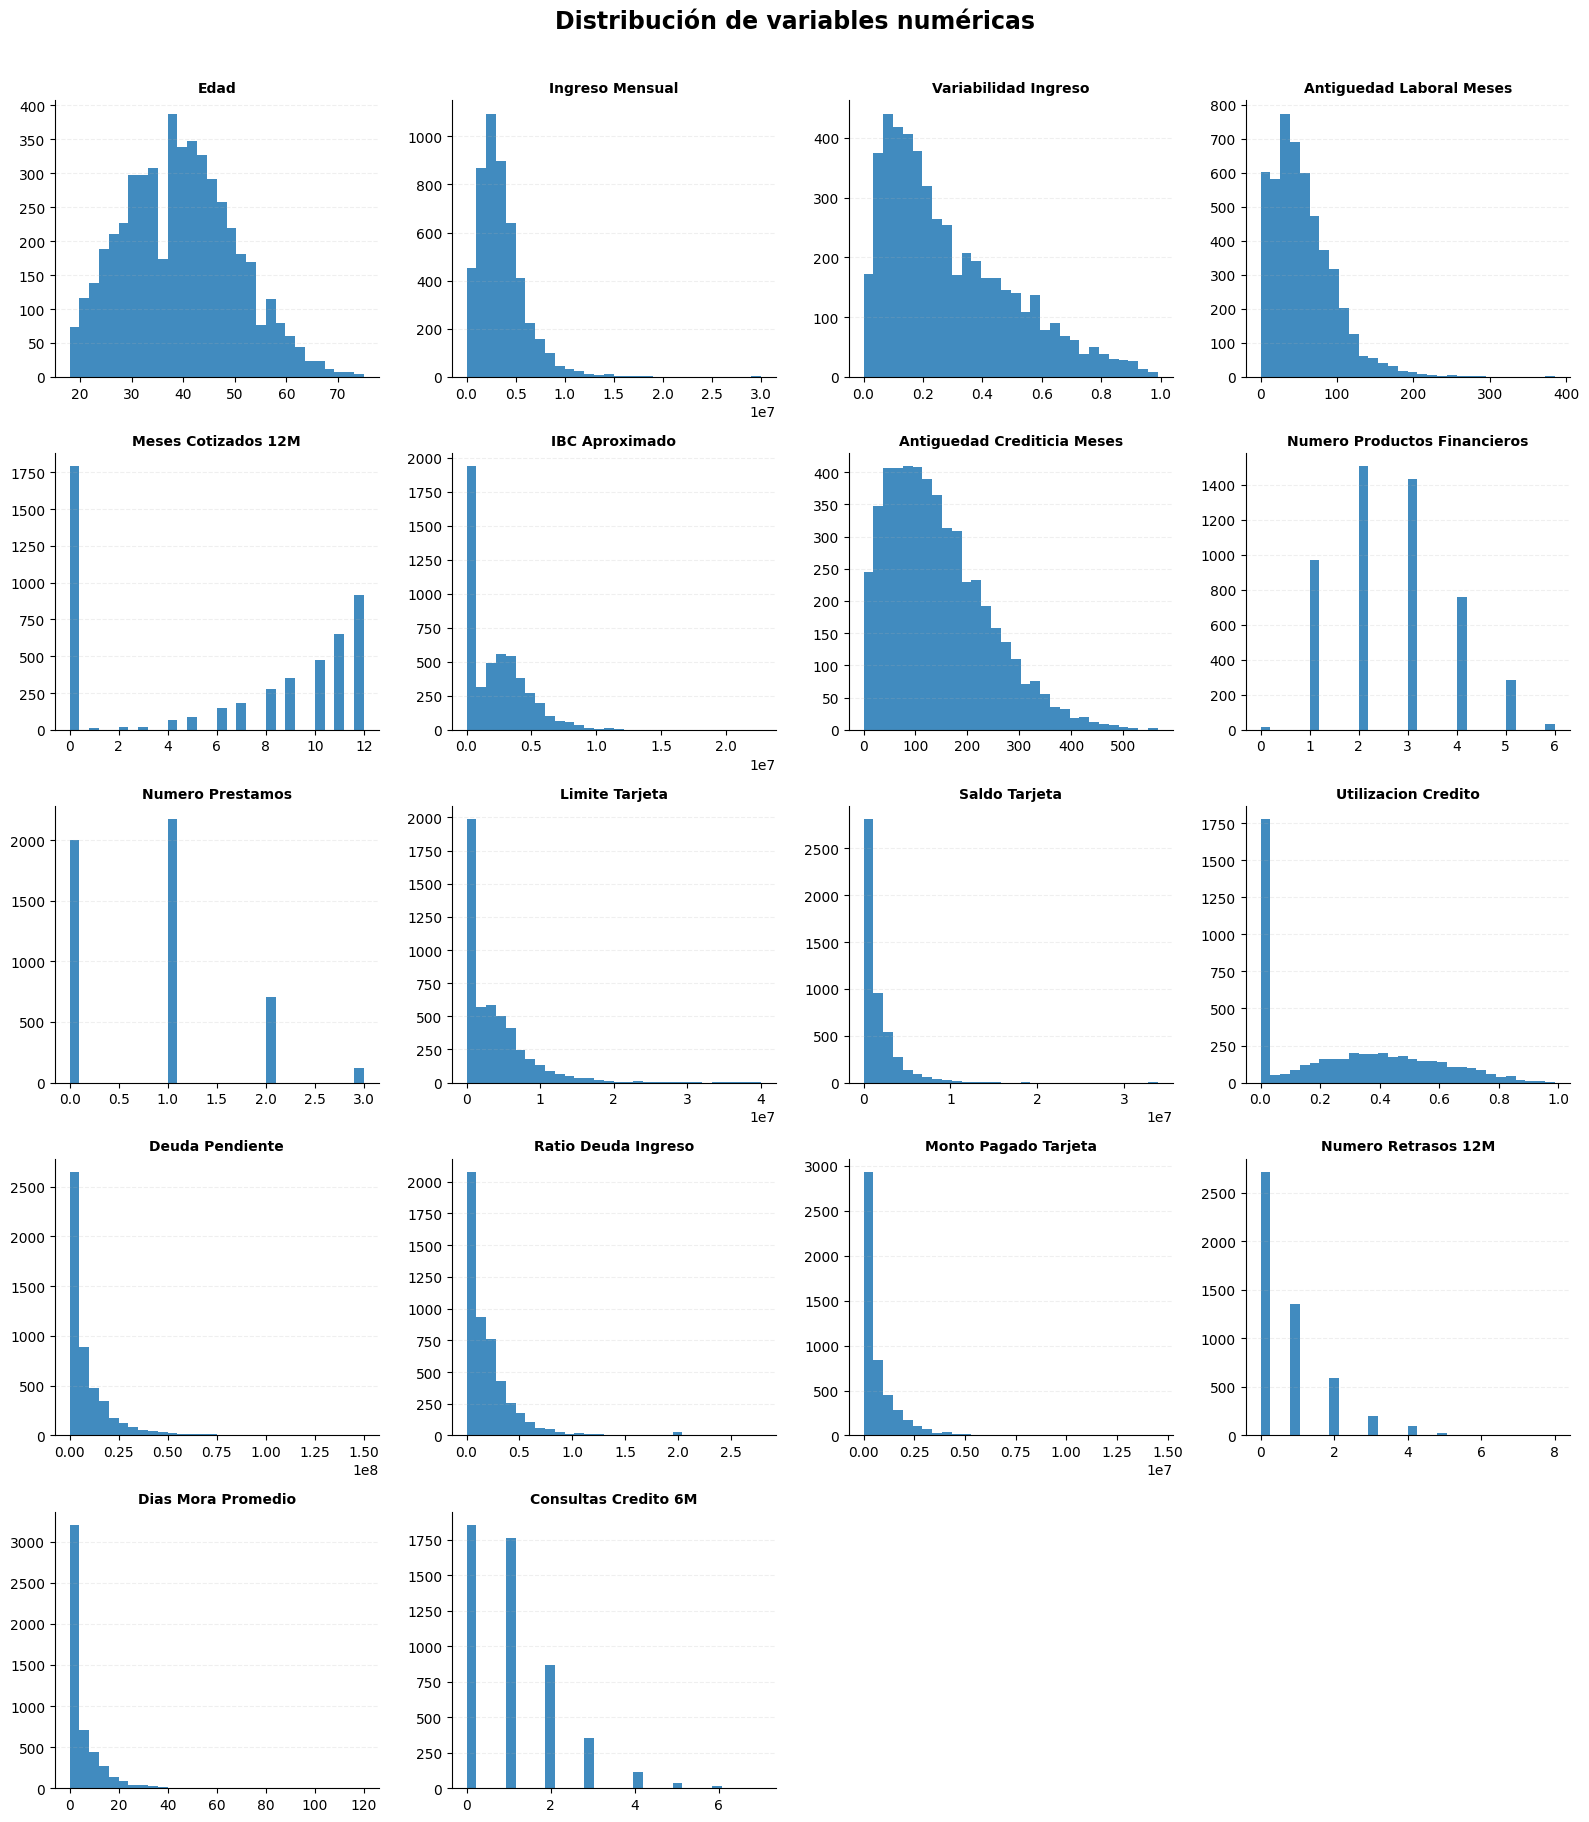

In [38]:
# 4. Distribución de variables numéricas

variables_numericas = [
    "Edad",
    "Ingreso_Mensual",
    "Variabilidad_Ingreso",
    "Antiguedad_Laboral_Meses",
    "Meses_Cotizados_12M",
    "IBC_Aproximado",
    "Antiguedad_Crediticia_Meses",
    "Numero_Productos_Financieros",
    "Numero_Prestamos",
    "Limite_Tarjeta",
    "Saldo_Tarjeta",
    "Utilizacion_Credito",
    "Deuda_Pendiente",
    "Ratio_Deuda_Ingreso",
    "Monto_Pagado_Tarjeta",
    "Numero_Retrasos_12M",
    "Dias_Mora_Promedio",
    "Consultas_Credito_6M"
]

fig, axes = plt.subplots(5, 4, figsize=(16, 18))
axes = axes.flatten()

for i, columna in enumerate(variables_numericas):
    axes[i].hist(
        df[columna],
        bins=30,
        alpha=0.85
    )

    axes[i].set_title(
        columna.replace("_", " "),
        fontsize=10,
        fontweight="bold"
    )

    axes[i].grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

for j in range(len(variables_numericas), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Distribución de variables numéricas",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()


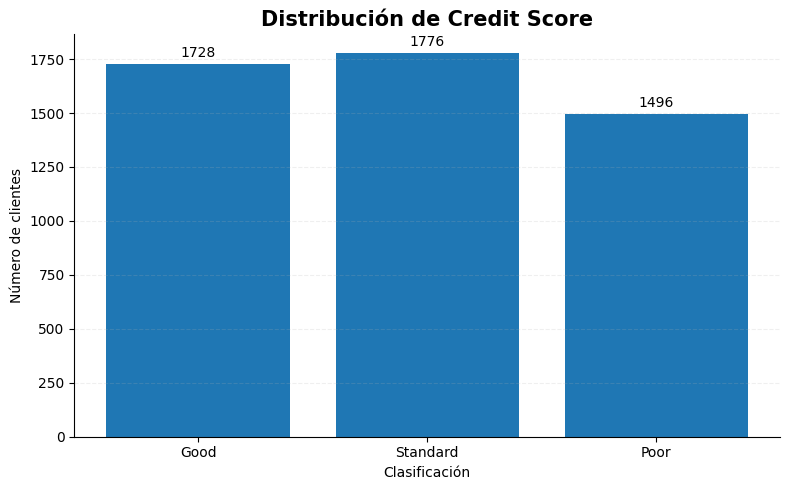

In [39]:
# 5. Distribución de Credit Score

orden_score = ["Good", "Standard", "Poor"]

conteo_target = (
    df["Credit_Score"]
    .value_counts()
    .reindex(orden_score)
)

plt.figure(figsize=(8, 5))

barras = plt.bar(
    conteo_target.index,
    conteo_target.values
)

plt.title(
    "Distribución de Credit Score",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Clasificación")
plt.ylabel("Número de clientes")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 20,
        f"{int(altura)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


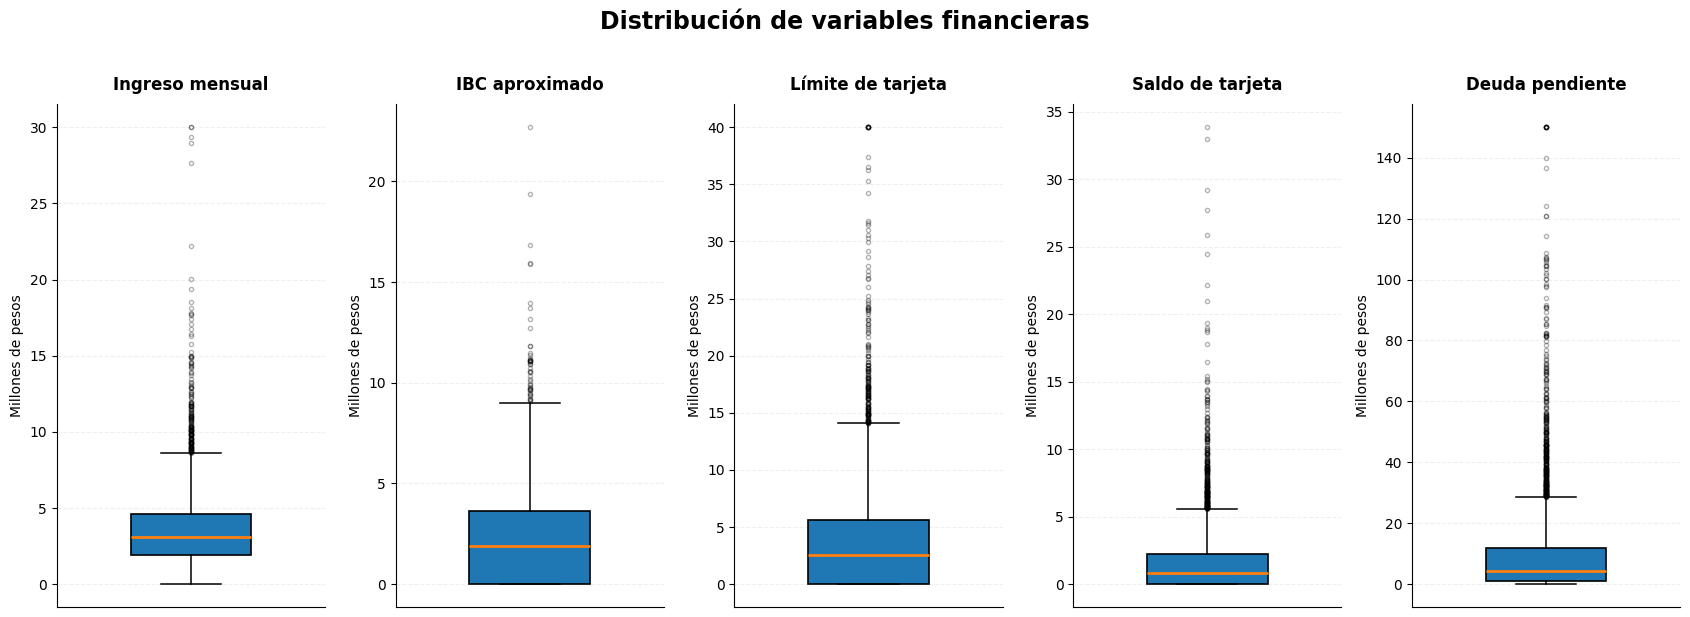

In [40]:
# 6. Boxplots de variables financieras

variables_financieras = {
    "Ingreso_Mensual": "Ingreso mensual",
    "IBC_Aproximado": "IBC aproximado",
    "Limite_Tarjeta": "Límite de tarjeta",
    "Saldo_Tarjeta": "Saldo de tarjeta",
    "Deuda_Pendiente": "Deuda pendiente"
}

fig, axes = plt.subplots(
    1,
    len(variables_financieras),
    figsize=(17, 6)
)

for ax, (columna, titulo) in zip(
    axes,
    variables_financieras.items()
):

    datos = df[columna] / 1_000_000

    ax.boxplot(
        datos,
        patch_artist=True,
        widths=0.45,
        showfliers=True,
        medianprops={"linewidth": 2},
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.1},
        capprops={"linewidth": 1.1},
        flierprops={
            "marker": "o",
            "markersize": 3,
            "alpha": 0.30
        }
    )

    ax.set_title(
        titulo,
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    ax.set_ylabel("Millones de pesos")
    ax.set_xticks([])

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Distribución de variables financieras",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


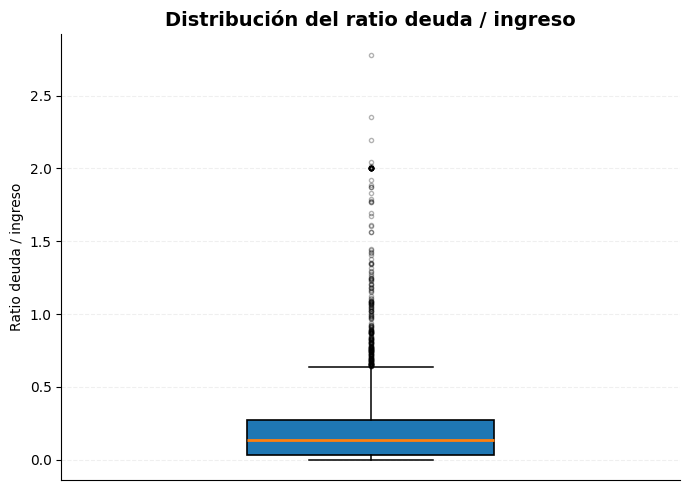

In [41]:
# 7. Boxplot del ratio deuda / ingreso

plt.figure(figsize=(7, 5))

plt.boxplot(
    df["Ratio_Deuda_Ingreso"],
    patch_artist=True,
    widths=0.40,
    showfliers=True,
    medianprops={"linewidth": 2},
    boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.1},
    capprops={"linewidth": 1.1},
    flierprops={
        "marker": "o",
        "markersize": 3,
        "alpha": 0.30
    }
)

plt.title(
    "Distribución del ratio deuda / ingreso",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Ratio deuda / ingreso")
plt.xticks([])

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [42]:
# 8. Promedios de variables de riesgo por Credit Score

variables_riesgo = [
    "Utilizacion_Credito",
    "Ratio_Deuda_Ingreso",
    "Numero_Retrasos_12M",
    "Dias_Mora_Promedio",
    "Consultas_Credito_6M",
    "Variabilidad_Ingreso",
    "Antiguedad_Crediticia_Meses"
]

resumen_riesgo = (
    df.groupby("Credit_Score")[variables_riesgo]
    .mean()
    .reindex(["Good", "Standard", "Poor"])
    .round(3)
)

resumen_riesgo


,Utilizacion_Credito,Ratio_Deuda_Ingreso,Numero_Retrasos_12M,Dias_Mora_Promedio,Consultas_Credito_6M,Variabilidad_Ingreso,Antiguedad_Crediticia_Meses
Credit_Score,,,,,,,
Good,0.203,0.148,0.446,2.785,0.951,0.253,155.611
Standard,0.257,0.178,0.642,3.822,1.056,0.294,142.602
Poor,0.382,0.306,1.215,7.688,1.178,0.328,129.857


La verificación por clase muestra el patrón previsto: la utilización media aumenta de Good a Poor, al igual que los retrasos, los días de mora y el ratio deuda-ingreso. En la ejecución final, las medias principales fueron:

| Credit_Score | Utilización | Retrasos 12M | Días de mora | Ratio deuda/ingreso |
|---|---:|---:|---:|---:|
| Good | 0.203 | 0.446 | 2.785 | 0.148 |
| Standard | 0.257 | 0.642 | 3.822 | 0.178 |
| Poor | 0.382 | 1.215 | 7.688 | 0.306 |

Estas relaciones no prueban causalidad; verifican que la simulación conserva la estructura de riesgo prevista.


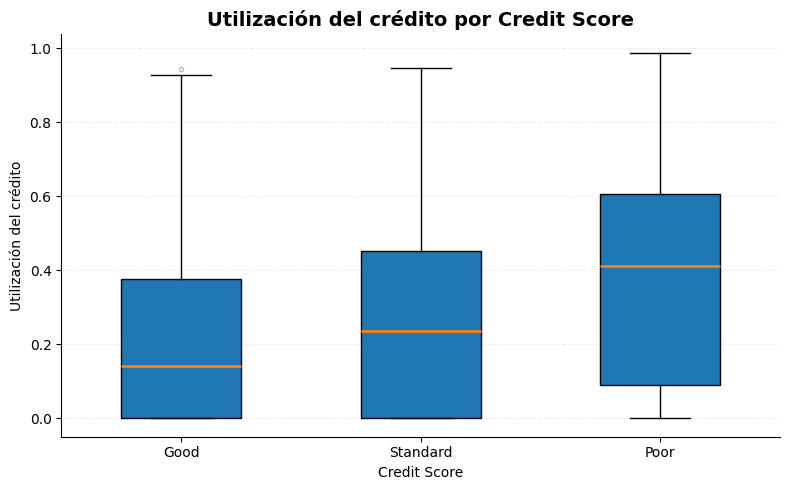

In [43]:
# 9. Utilización del crédito por Credit Score

orden_score = ["Good", "Standard", "Poor"]

datos_utilizacion = [
    df.loc[
        df["Credit_Score"] == clase,
        "Utilizacion_Credito"
    ]
    for clase in orden_score
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    datos_utilizacion,
    tick_labels=orden_score,
    patch_artist=True,
    widths=0.50,
    showfliers=True,
    medianprops={"linewidth": 2},
    flierprops={
        "marker": "o",
        "markersize": 3,
        "alpha": 0.25
    }
)

plt.title(
    "Utilización del crédito por Credit Score",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Credit Score")
plt.ylabel("Utilización del crédito")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


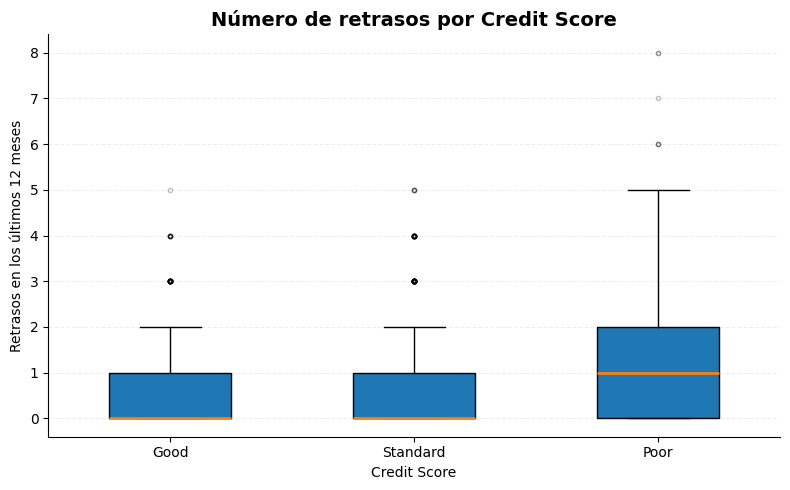

In [44]:
# 10. Retrasos por Credit Score

datos_retrasos = [
    df.loc[
        df["Credit_Score"] == clase,
        "Numero_Retrasos_12M"
    ]
    for clase in orden_score
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    datos_retrasos,
    tick_labels=orden_score,
    patch_artist=True,
    widths=0.50,
    showfliers=True,
    medianprops={"linewidth": 2},
    flierprops={
        "marker": "o",
        "markersize": 3,
        "alpha": 0.25
    }
)

plt.title(
    "Número de retrasos por Credit Score",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Credit Score")
plt.ylabel("Retrasos en los últimos 12 meses")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [45]:
# 11. Comportamiento de pago frente a Credit Score

tabla_pago_score = pd.crosstab(
    df["Comportamiento_Pago_Tarjeta"],
    df["Credit_Score"],
    normalize="index"
)

tabla_pago_score = (
    tabla_pago_score[
        ["Good", "Standard", "Poor"]
    ]
    .mul(100)
    .round(1)
)

tabla_pago_score


Credit_Score,Good,Standard,Poor
Comportamiento_Pago_Tarjeta,,,
No aplica,43.1,37.1,19.8
Pago irregular,4.0,6.0,90.0
Pago mínimo,10.7,22.3,67.0
Pago superior al mínimo,24.7,36.3,39.0
Pago total,44.0,37.7,18.3


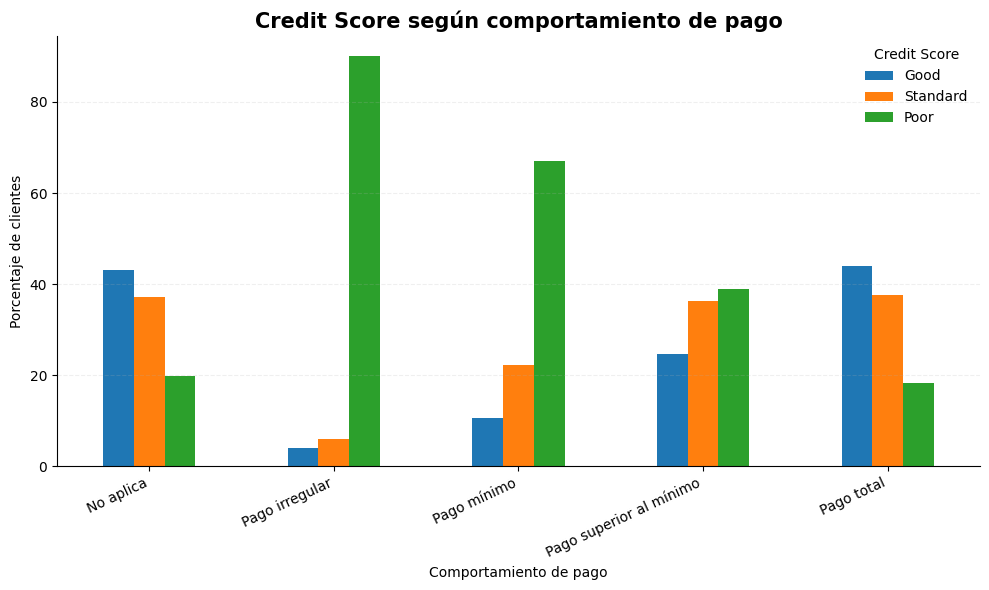

In [46]:
# 12. Distribución de Credit Score según comportamiento de pago

tabla_pago_score.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Credit Score según comportamiento de pago",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Comportamiento de pago")
plt.ylabel("Porcentaje de clientes")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    title="Credit Score",
    frameon=False
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


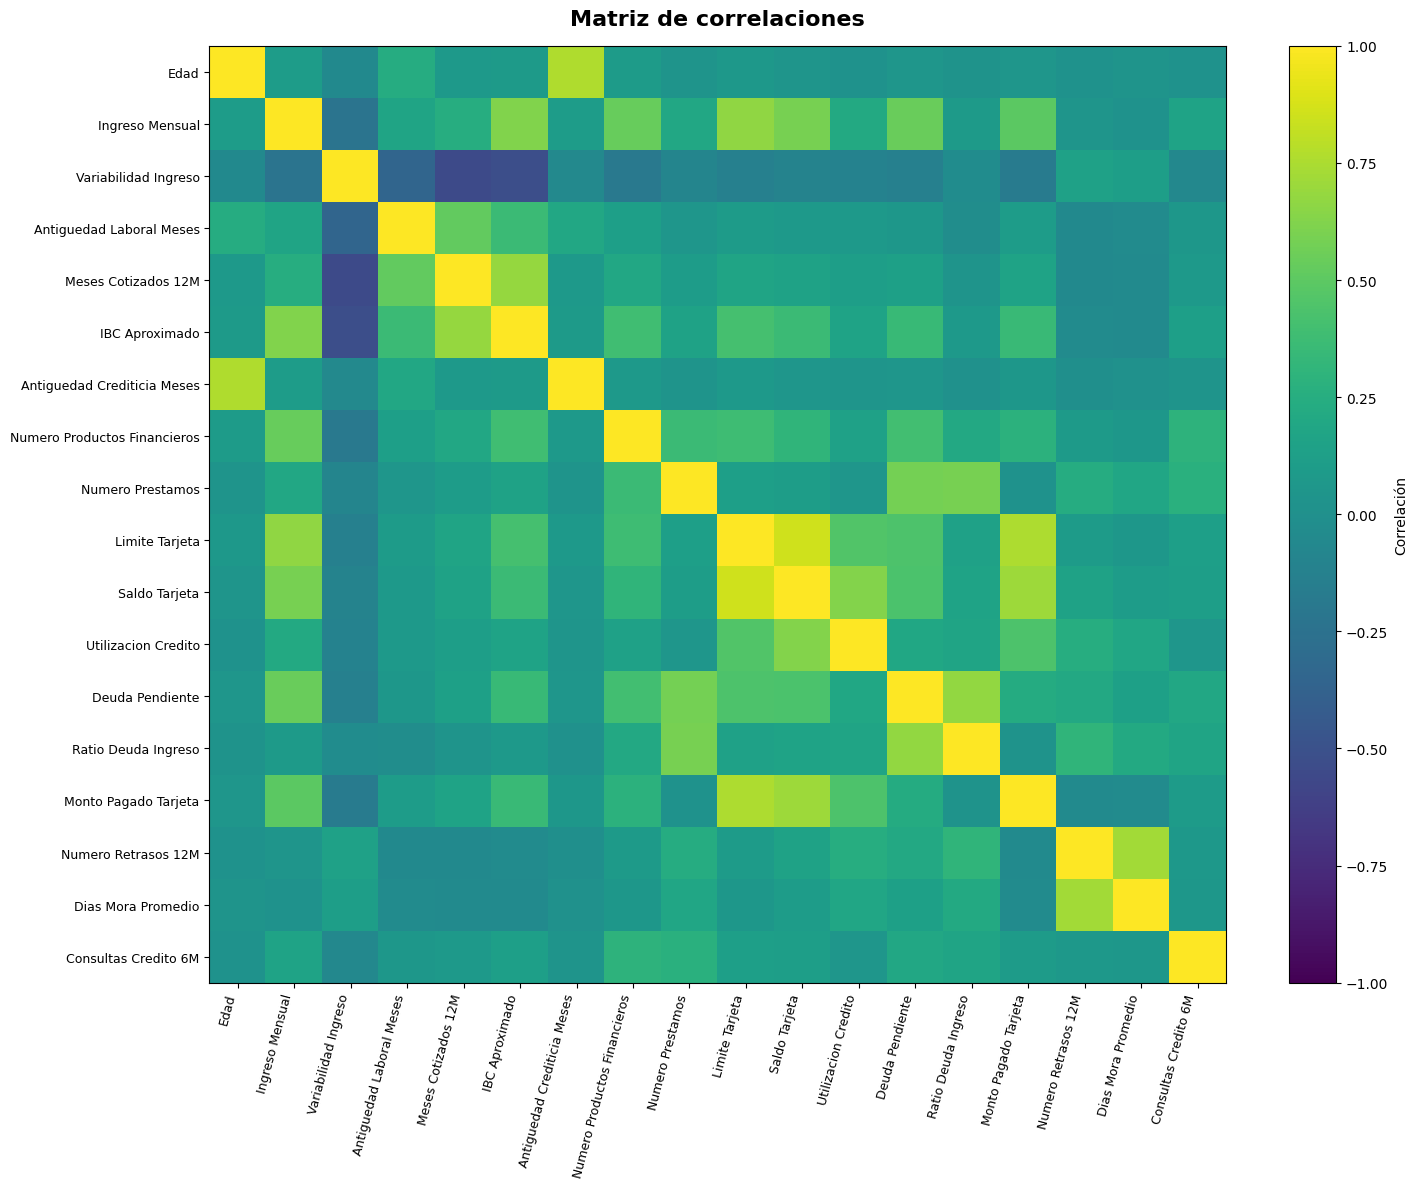

In [47]:
# 13. Matriz de correlaciones

columnas_correlacion = [
    "Edad",
    "Ingreso_Mensual",
    "Variabilidad_Ingreso",
    "Antiguedad_Laboral_Meses",
    "Meses_Cotizados_12M",
    "IBC_Aproximado",
    "Antiguedad_Crediticia_Meses",
    "Numero_Productos_Financieros",
    "Numero_Prestamos",
    "Limite_Tarjeta",
    "Saldo_Tarjeta",
    "Utilizacion_Credito",
    "Deuda_Pendiente",
    "Ratio_Deuda_Ingreso",
    "Monto_Pagado_Tarjeta",
    "Numero_Retrasos_12M",
    "Dias_Mora_Promedio",
    "Consultas_Credito_6M"
]

correlaciones = df[columnas_correlacion].corr()

plt.figure(figsize=(15, 12))

plt.imshow(
    correlaciones,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Correlación"
)

nombres_correlacion = [
    nombre.replace("_", " ")
    for nombre in correlaciones.columns
]

plt.xticks(
    range(len(nombres_correlacion)),
    nombres_correlacion,
    rotation=75,
    ha="right",
    fontsize=9
)

plt.yticks(
    range(len(nombres_correlacion)),
    nombres_correlacion,
    fontsize=9
)

plt.title(
    "Matriz de correlaciones",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()


In [48]:
# 14. Correlaciones más altas entre variables numéricas

numericas = df.select_dtypes(
    include=["int64", "float64"]
)

corr = numericas.corr()

pares = (
    corr
    .where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

pares.columns = [
    "Variable 1",
    "Variable 2",
    "Correlación"
]

pares["Correlación absoluta"] = (
    pares["Correlación"].abs()
)

pares.sort_values(
    "Correlación absoluta",
    ascending=False
).head(15).round(3)


,Variable 1,Variable 2,Correlación,Correlación absoluta
21,Antiguedad_Laboral_Meses,Antiguedad_Laboral_Años,1.000,1.000
154,Limite_Tarjeta,Saldo_Tarjeta,0.852,0.852
147,Tiene_Tarjeta_Credito,Utilizacion_Credito,0.784,0.784
6,Edad,Antiguedad_Crediticia_Meses,0.766,0.766
158,Limite_Tarjeta,Monto_Pagado_Tarjeta,0.752,0.752
187,Numero_Retrasos_12M,Dias_Mora_Promedio,0.724,0.724
165,Saldo_Tarjeta,Monto_Pagado_Tarjeta,0.707,0.707
85,Meses_Cotizados_12M,IBC_Aproximado,0.683,0.683
175,Deuda_Pendiente,Ratio_Deuda_Ingreso,0.678,0.678
45,Ingreso_Mensual,Limite_Tarjeta,0.669,0.669


## Criterio para el modelamiento

Credit_Score es la variable objetivo. Para evitar redundancia, Antiguedad_Laboral_Años se conserva para interpretación en el EDA, pero se excluye del modelamiento porque contiene la misma información que Antiguedad_Laboral_Meses.


# Preparación para el modelamiento

Se separa el conjunto de prueba antes de cualquier ajuste. El preprocesamiento se integra en un `Pipeline`, de modo que el escalamiento y la codificación se ajusten únicamente con los datos de entrenamiento de cada partición y se evite fuga de información.


In [49]:
X = df.drop(
    columns=[
        "Credit_Score",
        "Antiguedad_Laboral_Años"
    ]
)

y = df["Credit_Score"]

columnas_categoricas = [
    "Tipo_Ocupacion",
    "Formalidad_Laboral",
    "Tipo_Cotizante",
    "Comportamiento_Pago_Tarjeta"
]

columnas_numericas = [
    columna
    for columna in X.columns
    if columna not in columnas_categoricas
]

print("Variables predictoras:", X.shape[1])
print("Variables numéricas:", len(columnas_numericas))
print("Variables categóricas:", len(columnas_categoricas))


Variables predictoras: 23
Variables numéricas: 19
Variables categóricas: 4


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

distribucion_split = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).round(3)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
distribucion_split


Train: (4000, 23)
Test: (1000, 23)


,Train,Test
Credit_Score,,
Standard,0.355,0.355
Good,0.346,0.346
Poor,0.299,0.299


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            columnas_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        )
    ]
)


# Reproducción y adaptación del método del artículo

El artículo de referencia compara nueve modelos de clasificación. Para este proyecto se seleccionaron cinco de ellos: Decision Tree, Random Forest, XGBoost, Gradient Boosting y SVM, que fueron los modelos definidos desde la primera entrega. Además, se utiliza un DummyClassifier como línea base para verificar si los modelos realmente mejoran frente a una estrategia simple.

La selección de variables del artículo se basó principalmente en eliminar identificadores, atributos redundantes y variables con problemas de calidad. En este proyecto no existen identificadores personales y se dispone de 23 predictores finales; por ello se adopta una selección por dominio y redundancia, excluyendo Antiguedad_Laboral_Años porque duplica la información de Antiguedad_Laboral_Meses.

## Correspondencia de variables

| Artículo | Adaptación en el proyecto |
|---|---|
| Credit_Utilization_Ratio | Utilización del crédito |
| Outstanding_Debt | Deuda pendiente |
| Delay_from_due_date | Días promedio de mora |
| Num_of_Delayed_payment | Retrasos en 12 meses |
| Num_Credit_Inquiries | Consultas de crédito en 6 meses |
| Annual_Income | Ingreso mensual |
| Num_of_Loan | Número de préstamos |
| Payment_Behaviour | Comportamiento de pago |
| Credit_History_Age | Antigüedad crediticia |
| Occupation | Tipo de ocupación |

Además, se agregaron variables adaptadas al contexto colombiano como Formalidad_Laboral, Tipo_Cotizante, Meses_Cotizados_12M e IBC_Aproximado.

### Principales cambios frente al artículo

- Se usa OneHotEncoder en lugar de label encoding para las variables categóricas.
- El preprocesamiento se realiza dentro de un Pipeline para reducir el riesgo de fuga de información.
- Se utiliza **F1 macro** como métrica principal.
- El artículo trabaja con cerca de **100.000 registros**, mientras que este proyecto utiliza **5.000 datos sintéticos**.
- Se conservaron algunas variables que el artículo elimina porque son útiles para esta adaptación.

# Modelos candidatos y línea base
Se compararon los nueve modelos usados en el artículo y también un DummyClassifier como punto de referencia.
La métrica principal fue el F1 macro, porque evalúa las tres clases con el mismo peso y permite ver mejor el desempeño en Standard, que es la categoría más difícil de clasificar. Además, se revisó la matriz de confusión para analizar especialmente los errores entre Good y Poor.

In [52]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names"
)

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

encoder_modelos = LabelEncoder()
y_train_modelos = encoder_modelos.fit_transform(y_train)
y_test_modelos = encoder_modelos.transform(y_test)

# sparse_threshold=0 fuerza salida densa para que el mismo preprocesamiento
# sea compatible también con GaussianNB.
preprocesador_modelos = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), columnas_numericas),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ],
    sparse_threshold=0
)

modelos = {
    "Baseline": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", DummyClassifier(strategy="most_frequent"))
    ]),
    "Logistic Regression": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", LogisticRegression(max_iter=3000, random_state=SEED))
    ]),
    "Decision Tree": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", DecisionTreeClassifier(random_state=SEED))
    ]),
    "Random Forest": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", RandomForestClassifier(
            n_estimators=100,
            random_state=SEED,
            n_jobs=1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", GradientBoostingClassifier(random_state=SEED))
    ]),
    "XGBoost": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            random_state=SEED,
            eval_metric="mlogloss",
            tree_method="hist",
            n_jobs=1
        ))
    ]),
    "LightGBM": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", LGBMClassifier(
            n_estimators=50,
            learning_rate=0.05,
            random_state=SEED,
            verbosity=-1,
            n_jobs=1,
            force_col_wise=True
        ))
    ]),
    "SVM": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", SVC(kernel="rbf", C=1, gamma="scale"))
    ]),
    "AdaBoost": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", AdaBoostClassifier(
            n_estimators=50,
            learning_rate=0.5,
            random_state=SEED
        ))
    ]),
    "Naive Bayes": Pipeline([
        ("preprocesamiento", preprocesador_modelos),
        ("modelo", GaussianNB())
    ])
}


## Comparación inicial con validación cruzada estratificada

Se utilizan tres folds estratificados sobre el conjunto de entrenamiento para mantener un flujo reproducible y computacionalmente manejable. El conjunto de prueba permanece reservado.


In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

resultados_cv = []

for nombre, modelo in modelos.items():
    scores = cross_val_score(
        modelo,
        X_train,
        y_train_modelos,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    resultados_cv.append({
        "Modelo": nombre,
        "F1_macro_promedio": scores.mean(),
        "Desviacion": scores.std()
    })

resultados_cv = (
    pd.DataFrame(resultados_cv)
    .sort_values("F1_macro_promedio", ascending=False)
    .reset_index(drop=True)
)

resultados_cv.round(3)


,Modelo,F1_macro_promedio,Desviacion
0,Logistic Regression,0.484,0.008
1,AdaBoost,0.480,0.009
2,SVM,0.471,0.012
3,XGBoost,0.464,0.006
4,LightGBM,0.458,0.010
5,Gradient Boosting,0.458,0.007
6,Random Forest,0.451,0.014
7,Decision Tree,0.401,0.012
8,Naive Bayes,0.345,0.057
9,Baseline,0.175,0.000


# Ajuste de hiperparámetros


El ajuste se hizo solo con X_train, usando validación cruzada estratificada de 3 folds. Se ampliaron los rangos de búsqueda porque algunos mejores valores habían quedado en los límites. Se ajustaron principalmente SVM, Regresión Logística, Random Forest y AdaBoost, ya que fueron los modelos más relevantes en los resultados iniciales y en el artículo.

Decision Tree, LightGBM y Naive Bayes se dejaron únicamente como referencia porque tuvieron un desempeño inicial más bajo.


In [54]:
from sklearn.model_selection import GridSearchCV

cv_tuning = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

espacios_busqueda = {
    "Logistic Regression": {
        "modelo__C": [0.0001, 0.001, 0.005, 0.01]
    },
    "Gradient Boosting": {
        "modelo__n_estimators": [50, 100],
        "modelo__learning_rate": [0.03, 0.05],
        "modelo__max_depth": [2]
    },
    "SVM": {
        "modelo__C": [0.1, 0.5],
        "modelo__gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "modelo__n_estimators": [50, 100],
        "modelo__max_depth": [2],
        "modelo__learning_rate": [0.01, 0.03],
        "modelo__subsample": [0.8],
        "modelo__colsample_bytree": [0.8]
    },
    "Random Forest": {
        "modelo__n_estimators": [100],
        "modelo__max_depth": [4, 8],
        "modelo__min_samples_leaf": [1, 3],
        "modelo__max_features": ["sqrt"]
    },
    "AdaBoost": {
        "modelo__n_estimators": [50, 100],
        "modelo__learning_rate": [0.1, 0.3]
    }
}

busquedas = {
    nombre: GridSearchCV(
        estimator=modelos[nombre],
        param_grid=parametros,
        scoring="f1_macro",
        cv=cv_tuning,
        n_jobs=-1
    )
    for nombre, parametros in espacios_busqueda.items()
}


In [55]:
resultados_busqueda = []

for nombre, busqueda in busquedas.items():
    busqueda.fit(X_train, y_train_modelos)

    resultados_busqueda.append({
        "Modelo": nombre,
        "Mejor_F1_macro_CV": busqueda.best_score_,
        "Mejores_parametros": busqueda.best_params_
    })

resultados_busqueda = (
    pd.DataFrame(resultados_busqueda)
    .sort_values("Mejor_F1_macro_CV", ascending=False)
    .reset_index(drop=True)
)

resultados_busqueda


,Modelo,Mejor_F1_macro_CV,Mejores_parametros
0,Logistic Regression,0.487591,{'modelo__C': 0.001}
1,AdaBoost,0.486305,"{'modelo__learning_rate': 0.3, 'modelo__n_esti..."
2,SVM,0.476416,"{'modelo__C': 0.5, 'modelo__gamma': 'scale'}"
3,Gradient Boosting,0.476063,"{'modelo__learning_rate': 0.05, 'modelo__max_d..."
4,Random Forest,0.470931,"{'modelo__max_depth': 8, 'modelo__max_features..."
5,XGBoost,0.465599,"{'modelo__colsample_bytree': 0.8, 'modelo__lea..."


Los mejores parámetros y sus resultados aparecen en la celda anterior y se comparan con la validación inicial para ver si realmente mejoran el desempeño.
En algunos modelos, los mejores valores quedaron en el límite de la búsqueda, por lo que probar rangos más amplios podría generar pequeños cambios. Sin embargo, las diferencias entre los modelos son pequeñas y están dentro de la variación esperada. Por eso, la decisión final también se apoyó en la validación anidada. La Regresión Logística, que fue el modelo seleccionado, sí encontró su mejor configuración dentro del rango evaluado.

## Comparación de configuraciones ajustadas

Los mejores scores de búsqueda se comparan antes de la validación anidada. La selección definitiva no se basa solo en estas cifras, porque están condicionadas por el mismo conjunto de entrenamiento usado para elegir hiperparámetros.


In [56]:
resultados_ajustados = (
    resultados_busqueda[["Modelo", "Mejor_F1_macro_CV"]]
    .rename(columns={"Mejor_F1_macro_CV": "F1_macro_CV_ajuste"})
    .sort_values("F1_macro_CV_ajuste", ascending=False)
    .reset_index(drop=True)
)

resultados_ajustados.round(3)


,Modelo,F1_macro_CV_ajuste
0,Logistic Regression,0.488
1,AdaBoost,0.486
2,SVM,0.476
3,Gradient Boosting,0.476
4,Random Forest,0.471
5,XGBoost,0.466


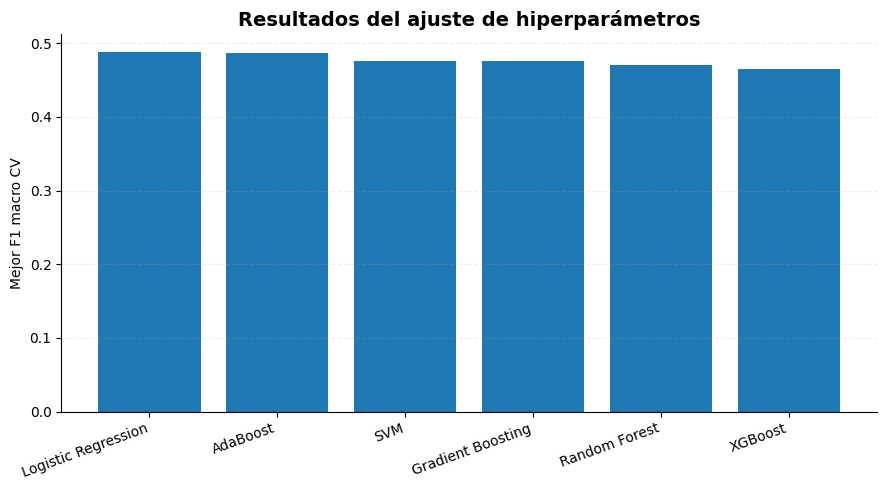

In [57]:
plt.figure(figsize=(9, 5))

plt.bar(
    resultados_ajustados["Modelo"],
    resultados_ajustados["F1_macro_CV_ajuste"]
)

plt.title(
    "Resultados del ajuste de hiperparámetros",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Mejor F1 macro CV")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.20)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


Los scores anteriores sirven para identificar finalistas, pero pueden ser optimistas porque se obtienen dentro del proceso de tuning. Por eso los dos primeros pasan a validación cruzada anidada.


## Validación cruzada anidada de los dos finalistas

Los dos modelos con mayor score de ajuste pasan a validación cruzada anidada con 3 folds externos y 2 internos. En cada fold externo, los hiperparámetros se seleccionan únicamente con los folds internos.


In [58]:
outer_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED + 11
)

inner_cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=SEED + 22
)

nombres_finalistas = resultados_ajustados.head(2)["Modelo"].tolist()
resultados_nested = []

for nombre in nombres_finalistas:
    scores = []

    for idx_train, idx_valid in outer_cv.split(X_train, y_train_modelos):
        busqueda = GridSearchCV(
            estimator=modelos[nombre],
            param_grid=espacios_busqueda[nombre],
            scoring="f1_macro",
            cv=inner_cv,
            n_jobs=-1
        )

        busqueda.fit(
            X_train.iloc[idx_train],
            y_train_modelos[idx_train]
        )

        pred = busqueda.best_estimator_.predict(
            X_train.iloc[idx_valid]
        )

        scores.append(
            f1_score(
                y_train_modelos[idx_valid],
                pred,
                average="macro"
            )
        )

    resultados_nested.append({
        "Modelo": nombre,
        "F1_macro_nested": np.mean(scores),
        "Desviacion": np.std(scores)
    })

resultados_nested = (
    pd.DataFrame(resultados_nested)
    .sort_values("F1_macro_nested", ascending=False)
    .reset_index(drop=True)
)

resultados_nested.round(3)


,Modelo,F1_macro_nested,Desviacion
0,Logistic Regression,0.471,0.006
1,AdaBoost,0.470,0.010


## Sensibilidad a variables monetarias asimétricas

Se probó la transformación log1p en las variables monetarias dentro del Pipeline del SVM. Se mantuvo el kernel RBF y los valores de C y gamma ya seleccionados. La comparación se hizo únicamente con validación cruzada sobre los datos de entrenamiento, sin utilizar el conjunto de test.


In [59]:
from sklearn.preprocessing import FunctionTransformer

columnas_monetarias = [
    "Ingreso_Mensual",
    "IBC_Aproximado",
    "Limite_Tarjeta",
    "Saldo_Tarjeta",
    "Deuda_Pendiente",
    "Monto_Pagado_Tarjeta"
]

columnas_numericas_no_monetarias = [
    c for c in columnas_numericas
    if c not in columnas_monetarias
]

preprocesador_log = ColumnTransformer(
    transformers=[
        (
            "monetarias_log",
            Pipeline([
                ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                ("scaler", StandardScaler())
            ]),
            columnas_monetarias
        ),
        (
            "numericas",
            StandardScaler(),
            columnas_numericas_no_monetarias
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        )
    ],
    sparse_threshold=0
)

svm_log = Pipeline([
    ("preprocesamiento", preprocesador_log),
    ("modelo", SVC(
        kernel="rbf",
        C=busquedas["SVM"].best_params_["modelo__C"],
        gamma=busquedas["SVM"].best_params_["modelo__gamma"]
    ))
])

scores_svm_log = cross_val_score(
    svm_log,
    X_train,
    y_train_modelos,
    cv=cv_tuning,
    scoring="f1_macro",
    n_jobs=-1
)

print("SVM con log1p - F1 macro CV:", round(scores_svm_log.mean(), 3))
print("Desviación:", round(scores_svm_log.std(), 3))


SVM con log1p - F1 macro CV: 0.474
Desviación: 0.012


## Balanceo y selección de variables

No se aplicaron técnicas de balanceo porque las tres clases tienen proporciones bastante similares: Standard 35,52 %, Good 34,56 % y Poor 29,92 %. Se mantiene F1 macro para dar el mismo peso a las tres clases, mientras que los tipos de error se revisan con la matriz de confusión.
Tampoco se usó un selector automático de variables. El dataset final no contiene identificadores personales ni variables de alta cardinalidad sin utilidad predictiva. Además, Antiguedad_Laboral_Años se eliminó antes del entrenamiento por ser redundante.


# Evaluación final

La Regresión logística ajustada se evalúa una única vez sobre el conjunto de prueba reservado.


In [60]:
mejor_nested = resultados_nested.iloc[0]

if (
    "Logistic Regression" in resultados_nested["Modelo"].values
    and mejor_nested["F1_macro_nested"]
    - resultados_nested.loc[
        resultados_nested["Modelo"] == "Logistic Regression",
        "F1_macro_nested"
    ].iloc[0] <= 0.01
):
    nombre_modelo_final = "Logistic Regression"
else:
    nombre_modelo_final = mejor_nested["Modelo"]

modelo_final = busquedas[nombre_modelo_final].best_estimator_
modelo_final.fit(X_train, y_train_modelos)

y_pred_final_num = modelo_final.predict(X_test)
y_pred_final = encoder_modelos.inverse_transform(
    y_pred_final_num.astype(int)
)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(
    y_test, y_pred_final, average="macro", zero_division=0
)
recall_final = recall_score(
    y_test, y_pred_final, average="macro", zero_division=0
)
f1_final = f1_score(
    y_test, y_pred_final, average="macro", zero_division=0
)

print(nombre_modelo_final, "- Evaluación final")
print("Accuracy:", round(accuracy_final, 3))
print("Precision macro:", round(precision_final, 3))
print("Recall macro:", round(recall_final, 3))
print("F1 macro:", round(f1_final, 3))


Logistic Regression - Evaluación final
Accuracy: 0.481
Precision macro: 0.482
Recall macro: 0.483
F1 macro: 0.481


In [61]:
print(
    classification_report(
        y_test,
        y_pred_final,
        labels=["Good", "Standard", "Poor"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

        Good       0.50      0.58      0.54       346
    Standard       0.41      0.36      0.38       355
        Poor       0.54      0.50      0.52       299

    accuracy                           0.48      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.48      0.48      0.48      1000



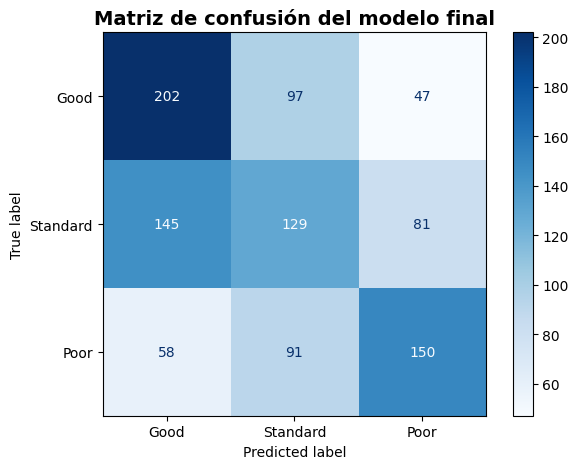

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    labels=["Good", "Standard", "Poor"],
    cmap="Blues"
)

plt.title(
    "Matriz de confusión del modelo final",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



La matriz de confusión muestra que el modelo acertó en 202 casos Good, 129 Standard y 150 Poor. Los errores más importantes fueron 105 casos en los que confundió directamente las categorías Good y Poor. Los demás errores se dieron principalmente con la categoría Standard, lo que muestra que es la clase que más se confunde con las otras dos.


## Intervalo de confianza del desempeño final

Se estima un intervalo de confianza bootstrap del 95 % para F1 macro sobre las 1.000 observaciones del conjunto de prueba.


In [63]:
rng_boot = np.random.default_rng(SEED + 900)
f1_bootstrap = []

y_test_array = np.asarray(y_test)
y_pred_array = np.asarray(y_pred_final)

for _ in range(1000):
    indices = rng_boot.integers(
        0,
        len(y_test_array),
        len(y_test_array)
    )

    f1_bootstrap.append(
        f1_score(
            y_test_array[indices],
            y_pred_array[indices],
            average="macro"
        )
    )

ic_95 = np.quantile(
    f1_bootstrap,
    [0.025, 0.975]
)

print(
    "IC 95 % F1 macro:",
    np.round(ic_95, 3)
)


IC 95 % F1 macro: [0.449 0.512]


# Techo teórico de la simulación
Como Credit_Score se generó de forma probabilística, siempre habrá cierto nivel de error. El modelo de referencia, usando las mismas 1.000 observaciones de test, obtuvo un F1 macro de 0.578, mientras que el modelo final logró 0.481. Esta diferencia se debe a que el modelo de referencia conoce directamente las probabilidades reales con las que se generaron las clases, mientras que la Regresión Logística debe aprenderlas a partir de las 23 variables disponibles. Además, algunas transformaciones usadas para generar el puntaje no están disponibles para el modelo final y también existe ruido en los datos.

In [64]:
indices = np.arange(len(df))

_, indices_test = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=df["Credit_Score"]
)

clases_oraculo = np.array([
    "Good",
    "Standard",
    "Poor"
])

pred_oraculo = clases_oraculo[
    np.argmax(
        probabilidades[indices_test],
        axis=1
    )
]

y_test_oraculo = (
    df.iloc[indices_test]["Credit_Score"]
    .to_numpy()
)

print(
    "Accuracy oráculo:",
    round(
        accuracy_score(
            y_test_oraculo,
            pred_oraculo
        ),
        3
    )
)

print(
    "F1 macro oráculo:",
    round(
        f1_score(
            y_test_oraculo,
            pred_oraculo,
            average="macro"
        ),
        3
    )
)


Accuracy oráculo: 0.572
F1 macro oráculo: 0.578


El F1 macro del oráculo es 0.578. Esto confirma que la simulación contiene ruido deliberado y que el techo predictivo es inferior a 1. La Regresión logística alcanza 0.481 en test; la brecha restante refleja la pérdida de información al estimar una frontera a partir de variables observadas, además del muestreo probabilístico de la etiqueta.


# Interpretación preliminar

Se utiliza permutation importance sobre el conjunto de prueba con 10 repeticiones. Se calculan las 23 variables originales; la gráfica muestra solo las 15 primeras para facilitar la lectura. Las barras de error representan la desviación estándar de las permutaciones.

Con variables correlacionadas, la importancia puede repartirse entre predictores relacionados, por lo que estos valores no deben interpretarse como efectos causales.


In [65]:
from sklearn.inspection import permutation_importance

importancia = permutation_importance(
    modelo_final,
    X_test,
    y_test_modelos,
    scoring="f1_macro",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1
)

importancias_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": importancia.importances_mean,
    "Desviacion": importancia.importances_std
}).sort_values(
    "Importancia",
    ascending=False
).reset_index(drop=True)

importancias_df.head(15).round(4)


,Variable,Importancia,Desviacion
0,Utilizacion_Credito,0.0180,0.0103
1,Meses_Cotizados_12M,0.0104,0.0075
2,Variabilidad_Ingreso,0.0025,0.0069
3,Edad,0.0020,0.0061
4,Antiguedad_Laboral_Meses,0.0020,0.0024
5,Tipo_Cotizante,0.0019,0.0032
6,Antiguedad_Crediticia_Meses,0.0011,0.0049
7,Saldo_Tarjeta,0.0006,0.0046
8,Numero_Productos_Financieros,0.0003,0.0037
9,Numero_Retrasos_12M,0.0002,0.0062


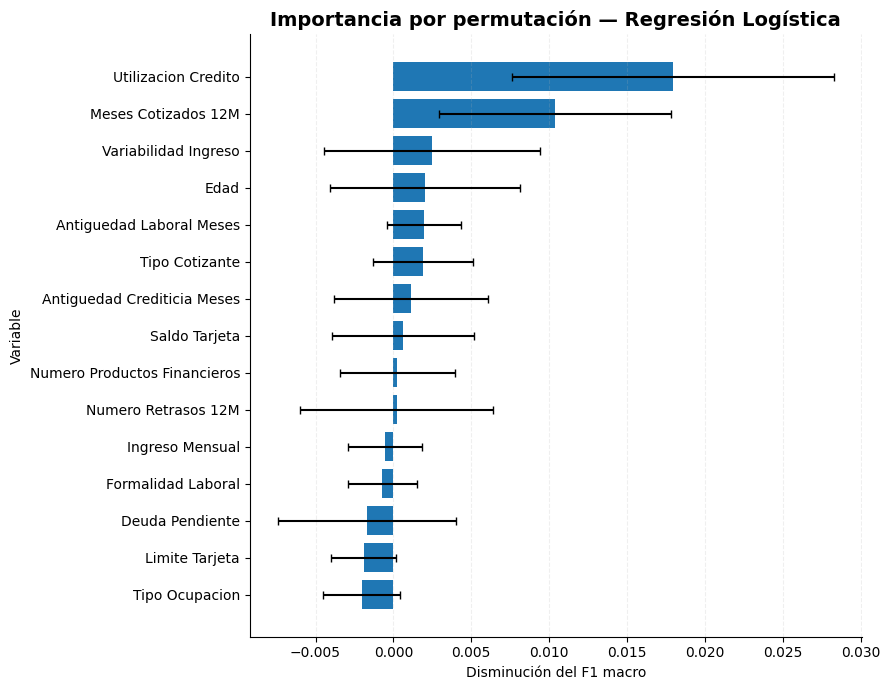

In [66]:
top_importancias = (
    importancias_df
    .head(15)
    .sort_values("Importancia")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_importancias["Variable"].str.replace("_", " "),
    top_importancias["Importancia"],
    xerr=top_importancias["Desviacion"],
    capsize=3
)

plt.title(
    "Importancia por permutación — Regresión Logística",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Disminución del F1 macro")
plt.ylabel("Variable")
plt.grid(axis="x", linestyle="--", alpha=0.20)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [67]:
correlaciones_edad = df[[
    "Edad",
    "Antiguedad_Crediticia_Meses",
    "Antiguedad_Laboral_Meses",
    "Numero_Productos_Financieros",
    "Limite_Tarjeta"
]].corr()["Edad"].drop("Edad")

correlaciones_edad.round(3)


,Edad
Antiguedad_Crediticia_Meses,0.766
Antiguedad_Laboral_Meses,0.237
Numero_Productos_Financieros,0.096
Limite_Tarjeta,0.063


Las correlaciones anteriores permiten interpretar la importancia de Edad con base en relaciones observadas en el dataset, evitando atribuciones no respaldadas por los datos.


# Contraste con el artículo
El artículo obtiene mejores resultados con Random Forest, pero no son directamente comparables con los nuestros porque los datos y su construcción son diferentes. Además, en nuestra simulación existe un componente aleatorio que limita la precisión máxima posible.

En el dataset de Kaggle hay varios registros por cliente y el paper no deja claro si `Customer_Id` fue eliminado ni si los clientes fueron separados entre entrenamiento y prueba, por lo que la comparación debe hacerse con cuidado.

Finalmente, aunque se probó una versión del SVM sobre test durante la exploración, la selección final se hizo con validación cruzada sobre entrenamiento.

# Fuentes de contexto

Consultadas el 1 de octubre de 2026.

- DANE. *Gran Encuesta Integrada de Hogares (GEIH) - Mercado laboral, empleo y desempleo*. https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/empleo-y-desempleo
- UGPP. *ABC Trabajador independiente por cuenta propia*. https://www.ugpp.gov.co/abc_cuenta_propia/
- Superintendencia Financiera de Colombia y Banca de las Oportunidades. *Reporte de Inclusión Financiera 2025*. https://www.superfinanciera.gov.co/publicaciones/10116222/reporte-de-inclusion-financiera-2025-avances-en-depositos-credito-cobertura-y-transacciones/
- Superintendencia Financiera de Colombia. *Estadísticas de la evolución de la cartera de créditos*. https://www.superfinanciera.gov.co/publicaciones/10115251/estadisticas-de-la-evolucion-de-la-cartera-de-creditos/
Estas fuentes se utilizan como anclas de contexto.

Los parámetros puntuales de la simulación siguen siendo supuestos explícitos del proyecto y no estimaciones oficiales de la población colombiana.


## Declaración de apoyo con IA

Se utilizó inteligencia artificial generativa como apoyo para depuración de código, revisión metodológica y redacción. El equipo comprende y toma las decisiones técnicas, los supuestos de simulación, el flujo de validación y la interpretación de los resultados.
